# Atividade Prática — Aula 4: Análise de Dados e Construção de Indicadores (KPIs)

Esta atividade foi construída com base na Aula 4, que marca a transição **do dado limpo para a tomada de decisão estratégica**, com foco em **KPIs, métricas derivadas, dimensões de análise, rankings e insights executivos**. fileciteturn5file0

## Ideia central da aula
Antes do código, vem a **pergunta de negócio**.  
Depois, definimos:
1. a **métrica**
2. a **dimensão**
3. a **agregação**
4. e só então construímos a resposta em tabela e em texto. fileciteturn5file0

## Regras da atividade
- O notebook **orienta**, mas você deve **escrever os códigos**.
- Sempre que gerar uma tabela agregada, escreva **1 ou 2 frases interpretando o resultado**.
- O objetivo não é apenas calcular números, mas comunicar decisões.

## Dataset da atividade
Arquivo: `vendas_brasil_aula4_kpis.csv`


## 1. Preparação do ambiente

Importe as bibliotecas necessárias para a atividade.

**Sugestão:**  
- `pandas`
- `numpy`

Se desejar, você também pode usar uma biblioteca de visualização mais adiante, mas o foco desta aula é **tabela agregada + insight**.


In [1]:
# Escreva aqui suas importações

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


## 2. Leitura da base

Leia o arquivo `vendas_brasil_aula4_kpis.csv` em um DataFrame chamado `df`.

Depois:
1. exiba as primeiras linhas
2. veja o tamanho da base
3. inspecione os tipos das colunas
4. confirme se `data_venda` está pronta para análises temporais


In [2]:
# Leia o CSV e faça a inspeção inicial

df = pd.read_csv('vendas_brasil_aula4_kpis.csv')
df.head()

,pedido_id,data_venda,uf,canal_venda,categoria,produto,quantidade_pedidos,preco_unitario,receita,lucro
0,5000,2025-02-14,RJ,Marketplace,Periféricos,Mouse Gamer,2,237.65,475.30,239.08
1,5001,2025-02-17,PR,Online,Informática,Monitor 27,4,1431.79,5727.16,1769.48
2,5002,2025-07-22,RJ,Marketplace,Informática,Monitor 27,5,1446.22,7231.10,2449.85
3,5003,2025-12-08,SP,Marketplace,Periféricos,Teclado Mecânico,7,399.84,2798.88,1356.67
4,5004,2025-01-04,GO,Marketplace,Telefonia,Smartphone X,4,3134.85,12539.40,3656.84


## 3. Perguntas antes do código

A aula enfatiza que a maior armadilha é começar com `groupby()` sem saber o que se quer responder. fileciteturn5file0

### Tarefa
Antes de programar, escreva em markdown respostas curtas para estas perguntas:

1. Qual canal de venda é o mais eficiente?
2. Qual categoria parece mais rentável?
3. Quais produtos são os campeões por lucro?
4. O negócio está crescendo ao longo do tempo?
5. Quais KPIs globais resumem melhor a operação?

Depois disso, avance para o código.


1 - Online parece ser o canal de venda mais eficiente devido à facilidade de compra e venda e pelo fato do dono do e-commerce ter o lucro total da venda


In [3]:
df.groupby(by='canal_venda')['lucro'].mean().sort_values(ascending=False)

,lucro
canal_venda,
Online,1353.753088
Marketplace,1317.748723
Loja Física,1220.861259


 2- Telefonia parece ser o mais rentável pela necessidade de se ter um celular e pelo preço que é vendido

In [4]:
df.groupby(by='categoria')['lucro'].mean().sort_values(ascending=False)

,lucro
categoria,
Informática,2355.808065
Telefonia,2018.124587
Áudio,495.549730
Periféricos,471.256075


3- Percebendo o lucro alto dos itens de informática, o notebook pode ser o item mais lucrativo

In [5]:
df.groupby(by='produto')['lucro'].mean().sort_values(ascending=False)

,lucro
produto,
Notebook Pro,3560.345116
Smartphone X,2110.683036
Tablet Plus,1920.326981
Monitor 27,1319.906200
Teclado Mecânico,585.156379
Caixa de Som,555.222941
Headset Pro,444.827500
Mouse Gamer,336.435306


4 -  O negócio parece estar vendendo muito bem ao longo do tempo, mostrando uma sazonalidade em épocas específicas do ano em que o consumo dos produtos é maior.

In [6]:
df['data_venda'] = df['data_venda'].astype('datetime64[ns]')
df['mes'] = df['data_venda'].dt.month
df.groupby(by='mes')['lucro'].mean()




,lucro
mes,
1,1224.082632
2,967.705484
3,956.946400
4,1002.186047
5,1318.883478
6,1169.475758
7,1754.952727
8,1240.036757
9,967.831515


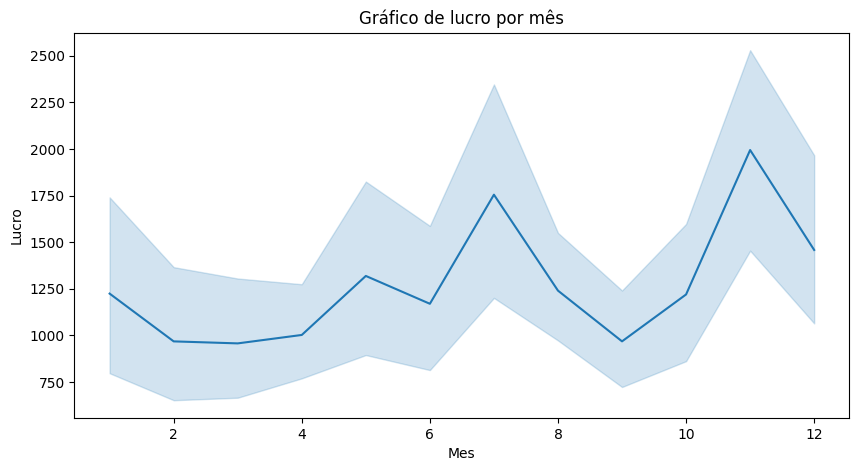

In [7]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x='mes', y='lucro')
plt.title('Gráfico de lucro por mês')
plt.xlabel('Mes')
plt.ylabel('Lucro')
plt.show()

5 - Os melhores KPIs são Receita total, Lucro total, Ticket Médio
(Receita/N° de Vendas), Variação da Receita

## 4. KPIs globais da operação

Com base nas “4 Métricas de Ouro do Varejo” apresentadas na aula, calcule os seguintes KPIs globais da base inteira: fileciteturn5file0

- **Receita Total**
- **Lucro Total**
- **Margem de Lucro (%)**
- **Ticket Médio**

### Orientação
- Pense primeiro na fórmula de cada KPI
- Escreva os cálculos em células separadas ou em uma pequena tabela-resumo
- Se quiser, formate os resultados para facilitar a leitura


### Tabela
* Receita total = Somatório das receitas de todos os produtos vendidos
* Lucro total = Somatório do lucro de todos os produtos vendidos
* Margem de lucro = Lucro Bruto(Receita - Custo) / Receita Total
* Ticket Médio = Receita total / N° de Vendas

In [8]:
# Calcule aqui os 4 KPIs globais

Receita_total = df['receita'].sum()
Receita_total
#R$ 1.921.492,22

np.float64(1921492.22)

In [9]:
Lucro_total = df['lucro'].sum()
Lucro_total
#R$ 544.496,15

np.float64(544496.15)

In [10]:
df['custo'] = df['receita'] - df['lucro']
Custo_Total = df['custo'].sum()
print(f'Custo total: R${Custo_Total:.2f}')
# R$ 1.376.996,07


Custo total: R$1376996.07


In [11]:
Lucro_Bruto = Receita_total - df['custo'].sum()
print(f'Lucro Bruto: R${Lucro_Bruto:.2f}')
# Lucro Bruto = Lucro total

Margem_de_Lucro = (Lucro_Bruto / Receita_total)
print(f'Margem de Lucro: {Margem_de_Lucro:.2%}') # Boa margem de lucro para o segmento de vendas de serviço

Ticket_Medio = Receita_total / df['quantidade_pedidos'].sum()
print(f'Ticket Medio: R${Ticket_Medio:.2f} por venda')

Lucro Bruto: R$544496.15
Margem de Lucro: 28.34%
Ticket Medio: R$1382.37 por venda


### Interpretação
Escreva 3 a 5 linhas respondendo:
- O negócio parece grande ou pequeno?
- O lucro acompanha bem a receita?
- O ticket médio sugere compras de maior valor ou de menor valor?


### Através das análises acima, o negócio já é grande devido ao Lucro gerado pelas vendas e uma receita bem alta. Porém, os custos de produção também são elevados, o que mostra que o produto é caro. O Ticket médio prova esta afirmação, revelando um ganho médio de mais de R$1.000 por produto vendido

## 5. Métricas derivadas

A aula mostra que **somar valores não basta**.  
Precisamos criar métricas derivadas para avaliar eficiência e comportamento. fileciteturn5file0

### Tarefa
Crie, quando fizer sentido:
- uma coluna de **margem_lucro** (`lucro / receita`)
- uma lógica para **ticket_medio** da operação ou por grupo

### Reflexão
Explique:
1. Por que receita alta não significa automaticamente melhor desempenho?
2. Em que situação a margem ajuda mais do que a receita bruta?


In [12]:
# Crie aqui as métricas derivadas
df['margem_lucro'] = df['lucro'] / df['receita']
df

df['ticket_medio'] = df['receita'] / df['quantidade_pedidos']
df['ticket_medio'] = df['ticket_medio'].round(2)
df



,pedido_id,data_venda,uf,canal_venda,categoria,produto,quantidade_pedidos,preco_unitario,receita,lucro,mes,custo,margem_lucro,ticket_medio
0,5000,2025-02-14,RJ,Marketplace,Periféricos,Mouse Gamer,2,237.65,475.30,239.08,2,236.22,0.503009,237.65
1,5001,2025-02-17,PR,Online,Informática,Monitor 27,4,1431.79,5727.16,1769.48,2,3957.68,0.308963,1431.79
2,5002,2025-07-22,RJ,Marketplace,Informática,Monitor 27,5,1446.22,7231.10,2449.85,7,4781.25,0.338794,1446.22
3,5003,2025-12-08,SP,Marketplace,Periféricos,Teclado Mecânico,7,399.84,2798.88,1356.67,12,1442.21,0.484719,399.84
4,5004,2025-01-04,GO,Marketplace,Telefonia,Smartphone X,4,3134.85,12539.40,3656.84,1,8882.56,0.291628,3134.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
415,5415,2025-02-23,RJ,Marketplace,Informática,Notebook Pro,4,4238.28,16953.12,4730.36,2,12222.76,0.279026,4238.28
416,5416,2025-12-03,PR,Loja Física,Periféricos,Teclado Mecânico,6,332.32,1993.92,786.18,12,1207.74,0.394289,332.32
417,5417,2025-04-28,RS,Online,Telefonia,Smartphone X,3,2717.23,8151.69,2209.32,4,5942.37,0.271026,2717.23
418,5418,2025-06-07,RS,Online,Telefonia,Tablet Plus,3,2290.19,6870.57,2232.72,6,4637.85,0.324969,2290.19


* Uma receita pode ser alta, mas não está sendo levado em consideração o custo total daquela produção. Se o custo também for alto, o lucro será baixo, o que não indica um grande desempenho de venda.

* A margem de lucro leva em consideração também todos os custos de produção daquele negócio. Essa métrica ajuda a entender se o negócio está realmente sendo rentável e eficiente.

## 6. Fatiando a realidade: análise por dimensão

A aula mostra que um KPI isolado não decide nada.  
É preciso perguntar: **como isso varia por canal, categoria, região e tempo?** fileciteturn5file0

### Tarefa
Liste, em markdown, quais colunas do dataset representam:
- métrica
- dimensão
- tempo


* Métrica: Preço unitário, receita, lucro, custo, margem_lucro, quantidade_pedidos, pedido_id
* Dimensao: Uf, canal_venda, categoria, produto
* Tempo: data_venda, mes

## 7. Análise por canal

### Pergunta de negócio
**Qual canal de venda é o mais eficiente?**

### Tarefa
Crie uma tabela agregada por `canal_venda` contendo, no mínimo:
- Receita Total
- Lucro Total
- Margem Média ou Margem Calculada
- Quantidade de pedidos
- Ticket Médio

### Depois responda
1. Qual canal gera mais receita?
2. Qual canal gera maior eficiência?
3. Se você fosse gestor, priorizaria volume ou margem?


In [13]:
# Gere aqui a tabela agregada por canal_venda
table_agg= df.groupby(by='canal_venda').agg({'receita':'sum',
                                 'lucro': 'sum',
                                 'margem_lucro': 'mean',
                                 'quantidade_pedidos': 'sum',
                                 'ticket_medio': 'mean'})

table_agg

,receita,lucro,margem_lucro,quantidade_pedidos,ticket_medio
canal_venda,,,,,
Loja Física,640797.06,174583.16,0.344944,445,1442.323706
Marketplace,657802.09,185802.57,0.347194,493,1350.529574
Online,622893.07,184110.42,0.352601,452,1489.639118


A receita maior é do marketplace, porém a maior margem de lucro é do online, o que mostra que quanto maior a receita, menor a margem de lucro. Como o lucro dos produtos está em equilíbrio, eu continuaria focando na margem para manter o negócio funcionando com êxito.

### Insight obrigatório
Escreva 1 ou 2 frases interpretando sua tabela, no estilo executivo:
- não apenas “o Online foi maior”
- mas o que isso **significa para a decisão**


## 8. Análise por categoria

### Pergunta de negócio
**Qual categoria é mais lucrativa e qual parece mais eficiente?**

### Tarefa
Crie uma tabela agregada por `categoria` com:
- Receita Total
- Lucro Total
- Margem
- Ticket Médio

### Depois responda
1. A categoria de maior receita também é a de maior margem?
2. Existe alguma categoria que parece vender bem, mas ser pouco eficiente?


In [14]:
# Gere aqui a tabela agregada por categoria
table_agg2= df.groupby(by='categoria').agg({'receita':'sum',
                                 'lucro': 'sum',
                                 'margem_lucro': 'mean',
                                 'ticket_medio': 'mean'})

table_agg2


,receita,lucro,margem_lucro,ticket_medio
categoria,,,,
Informática,805376.44,219090.15,0.287181,2761.572366
Periféricos,116923.08,50424.40,0.430776,301.064299
Telefonia,866292.45,219975.58,0.253866,2477.815688
Áudio,132900.25,55006.02,0.412276,361.674414


A margem de lucro e a receita são variáveis inversamente proporcionais, quanto maior a receita, a margem de lucro é menor (margem = lucro/receita). No resultado acima, produtos de telefonia tem uma ótima receita, porém, a manor margem de lucro entre todas as categorias. Isso pode acontecer devido ao alto custo de produção desses produtos.





## 9. Análise por região (UF)

### Pergunta de negócio
**Quais UFs concentram a operação?**

### Tarefa
Monte uma tabela por `uf` com:
- Receita Total
- Lucro Total
- Participação percentual da receita
- Ticket Médio

### Depois responda
1. Quais UFs concentram maior receita?
2. Existe concentração regional?
3. Se fosse necessário expandir ou reforçar logística, por onde você começaria?


In [15]:
# Gere aqui a análise por UF
table_agg3= df.groupby(by='uf').agg({'receita':'sum',
                                 'lucro': 'sum',
                                 'margem_lucro': 'mean',
                                 'quantidade_pedidos': 'sum',
                                 'ticket_medio': 'mean'}).sort_values(by='receita', ascending=False)
table_agg3

,receita,lucro,margem_lucro,quantidade_pedidos,ticket_medio
uf,,,,,
SP,246835.50,71022.16,0.368560,214,1052.391042
RJ,218631.91,63960.39,0.349948,155,1469.403158
PE,208457.44,58183.95,0.343734,162,1294.643818
MG,207614.69,61122.25,0.354065,163,1367.563409
SC,198143.47,60272.32,0.361705,134,1509.496000
RS,187048.31,49795.96,0.337935,126,1405.410930
ES,181113.70,49838.07,0.354032,120,1551.544359
PR,174136.19,46155.64,0.319427,105,1861.766857
BA,157082.99,42117.30,0.326469,110,1582.271429


SP e RJ tem as maiores receitas, o que mostra concentração regional. Expansão na região Sul do Brasil, onde se tem receita e lucro altos, mas bem menos produtos do que a região Sudeste

## 10. O motor da análise: agregações (groupby)

Nos slides, a lógica central é:
- `receita -> sum`
- `margem -> mean` ou cálculo derivado
- `produto -> count`
fileciteturn5file0

### Tarefa
Escolha **duas dimensões diferentes** e construa tabelas agregadas mostrando que você entendeu essa lógica.

Exemplos:
- por canal
- por categoria
- por UF
- por mês


In [19]:
# Demonstre aqui o uso de groupby com diferentes agregações

df.groupby(by='canal_venda').agg({'receita': 'sum'})

df.groupby(by='mes').agg({'margem_lucro': 'mean'})


,margem_lucro
mes,
1,0.350445
2,0.354747
3,0.342782
4,0.343454
5,0.333523
6,0.350999
7,0.342844
8,0.342685
9,0.359818


## 11. Campeões e vilões (Top N)

A aula destaca o poder dos rankings curtos e focados. fileciteturn5file0

### Tarefa
Crie:
- Top 10 produtos por **lucro**
- Top 10 produtos por **receita**
- 5 categorias ou UFs com **pior margem** ou pior desempenho

### Perguntas
1. Quem são os “campeões”?
2. Quem são os “vilões”?
3. Que ação tática poderia ser tomada com base nisso?


In [ ]:
# Monte aqui os rankings Top N

top10_lucro = df.groupby('pedido_id')['lucro'].mean().sort_values(ascending=False).head(10)
top10_lucro


,lucro
pedido_id,
5381,8114.19
5292,7477.55
5280,7292.40
5162,7062.75
5300,6514.05
5124,6227.75
5029,5877.75
5400,5786.16
5331,5502.80


In [ ]:
top10_lucro = df.groupby('pedido_id')['receita'].mean().sort_values(ascending=False).head(10)
top10_lucro

,receita
pedido_id,
5162,36459.81
5381,30303.49
5400,24690.78
5280,23346.85
5292,22345.75
5300,22289.35
5124,21890.70
5331,21672.25
5251,21129.20


In [24]:
df.groupby('uf').agg({'margem_lucro': 'mean'}).sort_values(by='uf',ascending=True).head(5)

,margem_lucro
uf,
BA,0.326469
ES,0.354032
GO,0.362878
MG,0.354065
PE,0.343734


## 12. Análise temporal

A aula reforça que sem tempo a análise fica estática. fileciteturn5file0

### Tarefa
1. Converta `data_venda` para data, se necessário
2. Crie colunas auxiliares como:
   - mês
   - trimestre (opcional)
3. Gere uma tabela agregada por mês com:
   - receita
   - lucro
   - ticket médio ou margem

### Depois responda
1. O lucro parece crescer ao longo do tempo?
2. O último trimestre foi melhor que o anterior?
3. Quais meses concentram as vendas de fim de ano?


In [35]:
# Faça aqui a análise temporal mensal

df.groupby(by='mes').agg({'margem_lucro': 'mean',
                         'receita':'sum',
                         'ticket_medio': 'mean'}).sort_values(by='mes',ascending=True)
#



,margem_lucro,receita,ticket_medio
mes,,,
1,0.350445,161571.89,1300.048947
2,0.354747,108587.03,1257.566452
3,0.342782,87902.22,1262.792000
4,0.343454,148930.46,1395.069535
5,0.333523,106355.17,1486.114783
6,0.350999,134685.83,1376.595152
7,0.342844,196651.96,1797.283030
8,0.342685,160240.62,1644.742432
9,0.359818,109291.03,1215.011515


A margem de lucro é sazonal e não cresce ao longo do tempo, sofre quedas e aumenta no final do ano. Os meses de dezembro, janeiro e fevereiro concentram os maiores percentuais de lucro, as maiores receitas também são no final do ano(novembro e dezembro)

## 13. Fluxo de investigação do analista

A aula apresenta a sequência:
**Pergunta -> Colunas necessárias -> Tipo de resposta/gráfico**. fileciteturn5file0

### Tarefa
Preencha, em markdown, pelo menos 3 exemplos no formato:

- **Pergunta de negócio:** ...
- **Colunas necessárias:** ...
- **Métrica/KPI:** ...
- **Tipo de resposta esperada:** tabela, ranking, tendência etc.


## 14. O insight exige palavras

Segundo a aula, o mercado valoriza quem comunica decisões, não apenas quem roda código. fileciteturn5file0

### Tarefa
Escolha **duas tabelas agregadas** que você criou e escreva, para cada uma, **1 ou 2 frases de interpretação executiva**.

Exemplo de estilo:
- “O canal X concentra maior volume de receita, mas o canal Y apresenta margem superior.”
- “Recomenda-se revisar custos/expansão/priorização com base nesse resultado.”


## 15. Case Varejo Brasil — Entrega final

A aula propõe quatro entregas centrais para o gestor. fileciteturn5file0

### Sua missão final
Organize o notebook para entregar:

1. **KPIs Globais**
2. **Tabelas por Dimensões Críticas**
   - por canal
   - por categoria
3. **Top 10 Produtos por Lucro**
4. **Conclusão final com pelo menos uma decisão tática**

### Importante
A conclusão final deve ser escrita em linguagem clara, direta e orientada à decisão.


## 16. Desafio extra (opcional)

Monte uma pequena tabela executiva final com:
- Receita Total
- Lucro Total
- Margem
- Ticket Médio

e depois crie uma segunda tabela por canal com os mesmos indicadores.

Compare os resultados e explique:
- o KPI global esconde alguma diferença importante entre os canais?


In [ ]:
# Desafio extra opcional


## 17. Entrega esperada

Seu notebook deve demonstrar:
- organização
- fórmulas corretas de KPI
- uso adequado de `groupby`, `agg`, `sort_values`
- leitura temporal coerente
- interpretação escrita dos resultados

### Mensagem principal da aula
Transformar linhas de dados limpos em **apoio real para decisões de negócio**. fileciteturn5file0
